In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Assumptions

steady incompressible (turbulent?)



In [91]:
measurement_data = np.loadtxt("data.txt")
t, p1, p2 = measurement_data[:,0], measurement_data[:,1], measurement_data[:,2]

L = 9
L2 = 8.8
D = 0.1
f = 0.02  # friction factor
R_specific = 286.9  # J /(kg*K)  for dry air
p_atmospheric = 99700  # Pa
Temperature = 26 + 273.15  # Kelvin
rho = p_atmospheric / (R_specific * Temperature)
print(rho)

1.1616508188327486


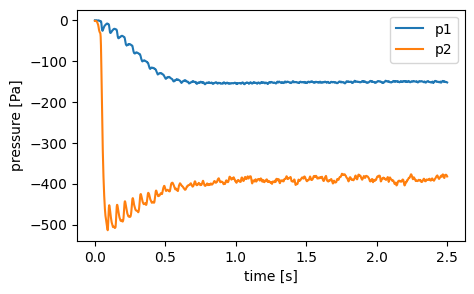

In [84]:
plt.figure(figsize=(5, 3))
plt.plot(t, p1, label="p1")
plt.plot(t, p2, label="p2")
plt.xlabel("time [s]")
plt.ylabel("pressure [Pa]")
plt.legend()

In [ ]:
delta_p = p1-p2
v_mean = np.sqrt(2 * delta_p * D / (f * L * rho))
v1 = np.sqrt(-2*p1 / (rho))

[  -1.8   -1.8   -1.7 ... -532.8 -533.8 -534.7]


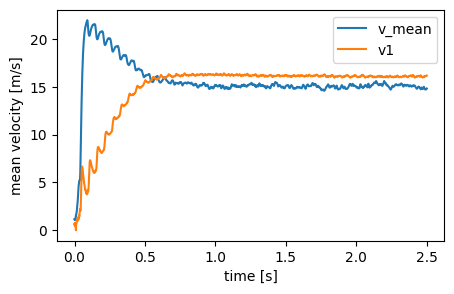

In [89]:
plt.figure(figsize=(5,3))
plt.plot(t, v_mean, label="v_mean")
plt.plot(t, v1, label="v1")
plt.xlabel("time [s]")
plt.ylabel("mean velocity [m/s]")
plt.legend()

In [105]:
def dydt(t, y):
    return (-100 + 400) / (rho * L2) - f / (2*D) * y**2

def dydt2(t, y):
    return -2 * y

In [106]:
y0 = [0]

t_span = (0, 2.5)

solution = solve_ivp(dydt, t_span, y0, t_eval=np.linspace(t_span[0], t_span[1], 100))

In [119]:
mable_sol = ( np.tanh(t * np.sqrt(delta_p*D*L2*f*rho*2) /2*rho*L2*D) * np.sqrt(delta_p * D * L2 * f * rho*2) ) / (L2*f*rho)

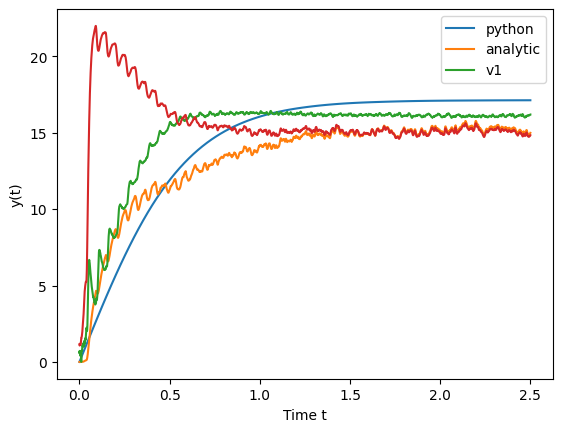

In [124]:
plt.plot(solution.t, solution.y[0], label="python")
plt.plot(t, mable_sol, label="analytic")
plt.plot(t, v1, label="v1")
plt.plot(t, v_mean)
plt.xlabel('Time t')
plt.ylabel('y(t)')
plt.legend()